# CREO Lead Prioritization Tool — Presentation Slide Deck
**Presenter:** Rosie Wang | **Date:** March 9, 2026 | **Duration:** 10 minutes

---

### How to use this notebook
- Each section below = **one slide**
- **LAYOUT** describes what to put on the slide in your slide builder (PowerPoint / Google Slides / Canva)
- **Script** is your word-for-word speaking guide, timed for 10 minutes total
- Charts are rendered from the actual **2,500-row dataset** — run each code cell to view them
- `📸 [PHOTO]` markers show exactly where to insert UI screenshots

### Timing Guide
| # | Slide | Time |
|---|---|---|
| 0 | Title | ~0:30 |
| 1 | Intro — Problem, Tools, Process | ~1:30 |
| 2 | Analysis — Key Data Findings | ~2:30 |
| 3 | The Scoring Model | ~2:00 |
| 4 | The Product | ~2:00 |
| 5 | Summary + Next Steps | ~1:30 |
| | **Total** | **~10:00** |


In [2]:
from IPython.display import Image, display, HTML
import os

CHARTS = os.path.join('..', 'backend', 'data', 'charts')

def show(name, width=750, caption=""):
    path = os.path.join(CHARTS, name)
    display(Image(path, width=width))
    if caption:
        display(HTML(
            f'<p style="text-align:center;color:#555;font-style:italic;'
            f'font-size:0.88em;margin-top:4px">{caption}</p>'
        ))

print("Setup complete. Run cells top-to-bottom to view the full slide deck.")


Setup complete. Run cells top-to-bottom to view the full slide deck.


---
## SLIDE 0 — Title Slide

---

**LAYOUT:** Clean, minimal. White background. Large centered text only — no bullets, no icons.

---

> ### Lead Prioritization Engine for CREO Solutions
> *From 2,500 Unranked Leads to a Clear Daily Call Priority List*
>
> Rosie Wang
> March 9, 2026

---

**Design note:** Keep this slide completely empty except the title, subtitle, name, and date.
The simplicity signals confidence. Let the title speak.

---

### 🎙️ Script (~30 sec)

*"Thank you for having me. I'm Rosie Wang.*
*What I built is a system that takes CREO's 2,500 inbound leads and assigns every one of them a
priority score — so your sales team knows exactly who to call first, and why.*
*I'll walk you through the analysis I ran, the decisions I made, and the tool I built."*


---
## SLIDE 1 — Intro: Problem · Tools · Process

---

**LAYOUT:** Three columns — Problem | Tech Stack | Process Flow

---

#### Column 1 — The Problem

- CREO receives hundreds of inbound leads per month
- Without ranking: every lead is treated equally
- A renter from a Facebook ad gets the same call as a referred homeowner ready to book this week
- **Cost:** high-value leads are missed while low-intent inquiries consume sales capacity
- **The opportunity:** CREO's own data already contains the signals that distinguish them

---

#### Column 2 — Tools Used

| Layer | Technology |
|---|---|
| Data processing | Python, pandas |
| ML model | XGBoost |
| API | FastAPI |
| Frontend | Next.js, TypeScript |
| AI text parsing | Gemini 2.5 Flash (Google) |
| Database | Supabase (PostgreSQL) |

---

#### Column 3 — Process Breakdown

```
Fetch 2,500 leads from Supabase
           ↓
   Clean & normalize data
           ↓
Explore patterns in the data
           ↓
Train XGBoost → score all 2,500
           ↓
FastAPI backend + Next.js dashboard
           ↓
AI text analyzer → instant scoring
   from any email, call, or message
```

---

### 🎙️ Script (~1:30)

*"I'll start with the problem.*

*CREO generates hundreds of inbound leads every month. Right now, the sales team works through
them without any ranking — which means a renter who clicked a Facebook ad gets the same
attention as a homeowner who was personally referred and needs work done this week.
That's a significant opportunity cost: your highest-value leads aren't getting prioritized.*

*The insight I started with: CREO's own data already contains signals that predict which leads
are worth pursuing. Homeownership status, job size, how urgently they need the work —
these aren't vague hunches. Industry research has quantified their impact on conversion rates.
What I built is a system that reads those signals and turns them into a single priority score.*

*For tools: Python and pandas for data processing, XGBoost for the machine learning model,
FastAPI for the backend, and Next.js for the frontend. For AI-assisted intake I used
Google Gemini to parse freeform text — emails, voicemails, chat messages — into structured
lead fields automatically.*

*The process was: fetch the data, clean it, explore it to understand the patterns, train
a model, and surface everything through a web interface that any sales rep can use
without training."*


---
## SLIDE 2 — Analysis: Key Data Findings

---

**LAYOUT:** Slide title at top. Three charts — 2 side by side + 1 below (or 3 in a row).
Include the key callout box prominently.

**Slide title:** *"What the Data Tells Us"*

---

**Key callout box — make this visually prominent on the slide:**
> ⚠️ **50% of leads had no profit band label**
> → Machine learning was required to score all 2,500

---

**Annotations to add in your slide builder:**
- Chart 1: *"~1,250 labeled rows became the ML training set — the other half is what we needed to predict"*
- Chart 2: *"Word of Mouth: ~57% High-profit proportion vs ~25% for Facebook Ads"*
- Chart 3: *"Renters: highest Low-profit share — structurally unable to authorize exterior work"*

---

*Run the three code cells below to view the charts.*


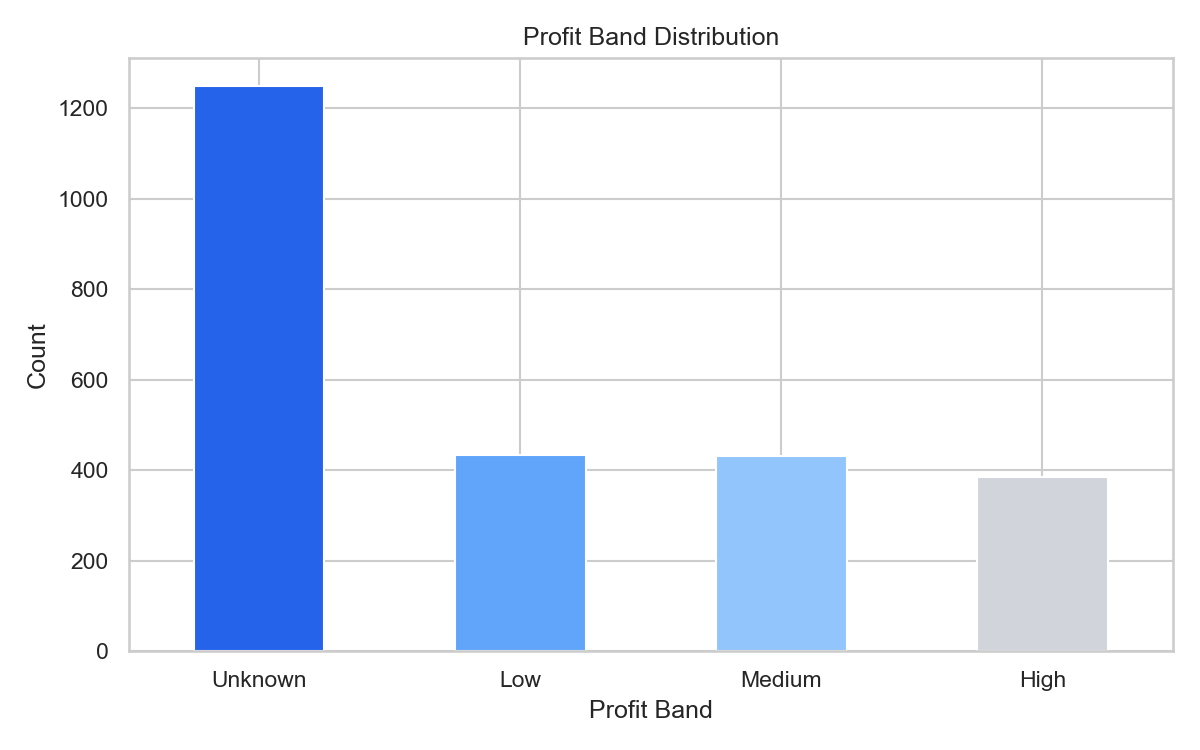

In [3]:
show(
    'eda_profit_band_dist.png',
    caption=(
        'Chart 1 — Profit Band Distribution (2,500 leads): ~1,250 unlabeled (Unknown). '
        'Labeled rows: Low ≈ 435, Medium ≈ 430, High ≈ 385. '
        'The unlabeled half is the problem the ML model solves.'
    )
)


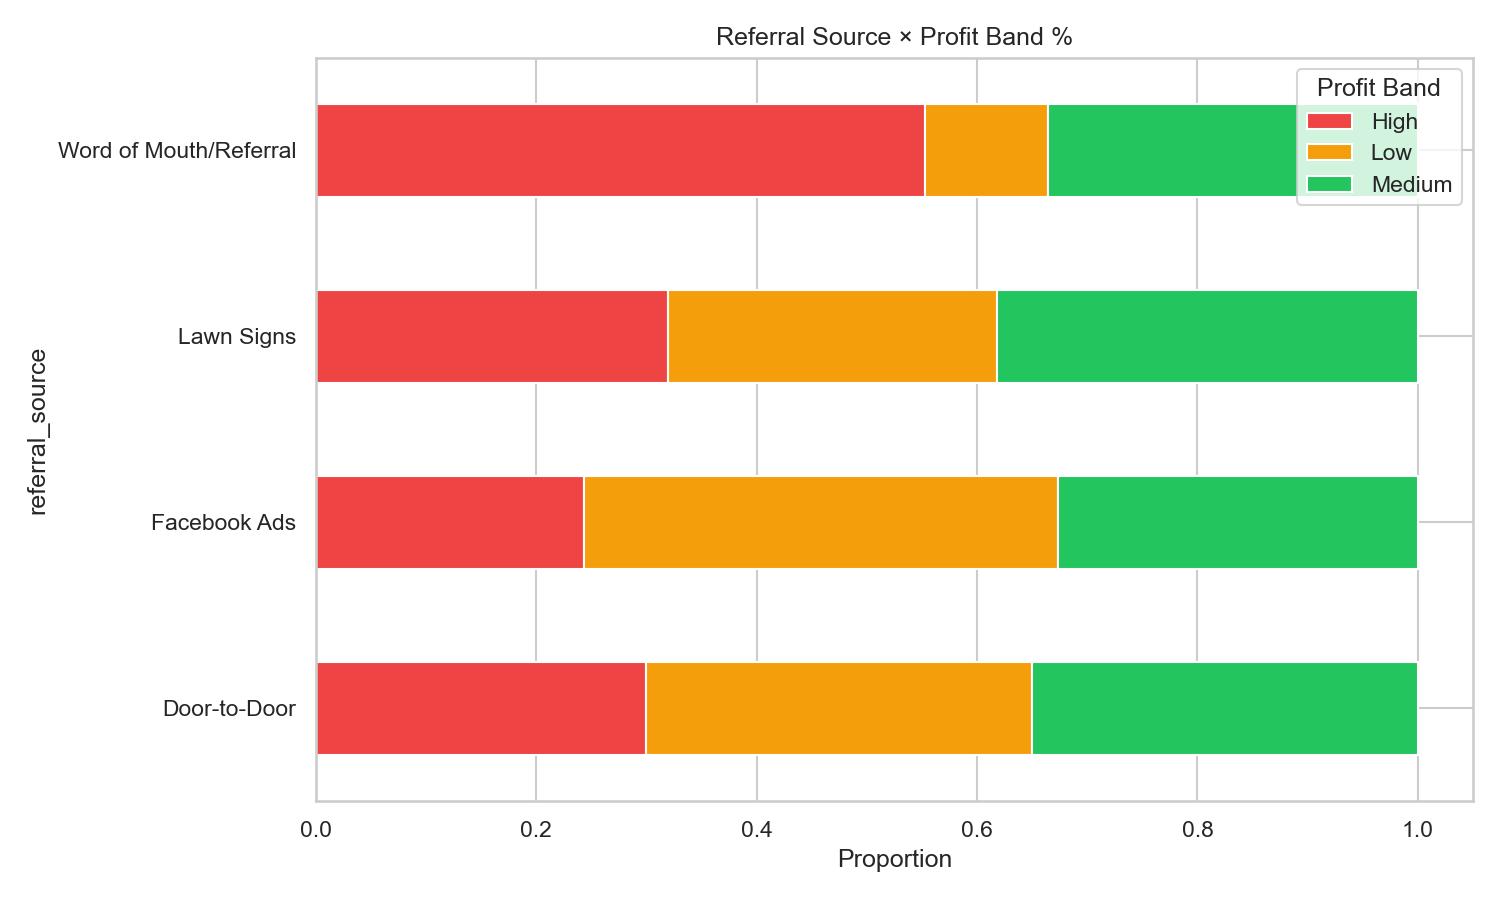

In [4]:
show(
    'eda_referral_vs_band.png',
    caption=(
        'Chart 2 — Referral Source × Profit Band %: '
        'Word of Mouth/Referral leads have ~57% High-profit proportion vs ~25% for Facebook Ads. '
        'Source: Jobber 2023, HubSpot 2023 — referral leads convert 3–5× more than cold outreach.'
    )
)


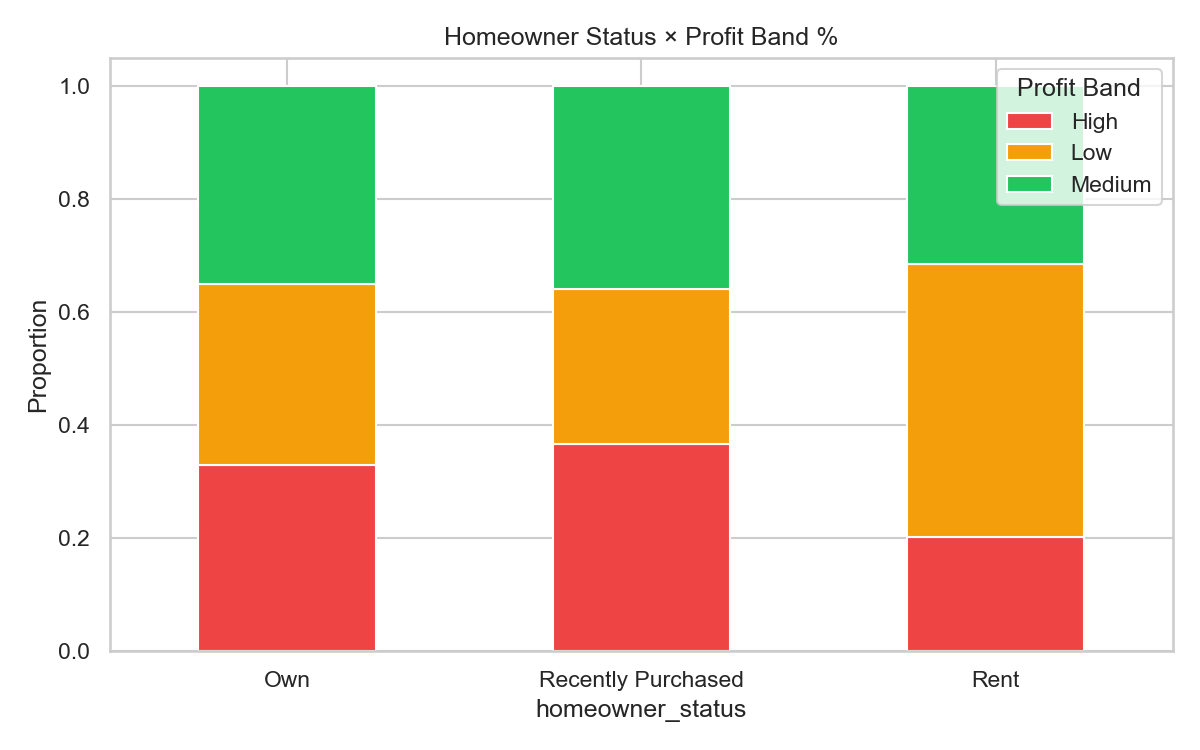

In [5]:
show(
    'eda_homeowner_vs_band.png',
    caption=(
        'Chart 3 — Homeowner Status × Profit Band %: '
        'Renters show the highest Low-profit proportion and lowest High-profit share. '
        'Recently Purchased homeowners have the highest High-band rate — '
        'new homeowners rank painting #1 in their first year (NAR 2022, Angi 2022).'
    )
)


### 🎙️ Script (~2:30)

*"Let me show you what I found in the data.*

*The first thing I noticed — and this shaped the entire approach — is that roughly half the
2,500 leads had no profit band label. The business had manually classified about 1,250 leads
as Low, Medium, or High expected profit, but never got to the rest.*
*So before I could score all 2,500 leads, I needed a way to fill that gap.*
*That's the ML model's primary job — but first, exploratory analysis.*

*[Chart 1] Here's the label distribution. About 1,250 Unknown rows — those are the leads
we couldn't rank without a model.*

*[Chart 2] This was one of the clearest findings: Word of Mouth referrals have roughly 57%
High-profit proportion, compared to about 25% for Facebook Ads and around 30% for
other cold channels. This matches published benchmarks — Jobber and HubSpot both report
referral leads convert at 3 to 5 times the rate of cold outreach. The data didn't just
confirm the research — it validated it specifically for CREO's customer base.*

*[Chart 3] Homeowner status tells an equally clear story. Renters have the highest
Low-profit proportion and the lowest High-profit share. This is structural —
renters need landlord approval to authorize exterior painting, so they represent
a fundamentally different conversion path. What's interesting is that 'Recently Purchased'
homeowners actually have the highest High-band rate. Angi and NAR data both show:
new homeowners rank painting as the number one home improvement project in their first year,
with typical spend of $4,000 to $9,000.*

*With these patterns confirmed in the data, I built a scoring system grounded in them."*


---
## SLIDE 3 — The Scoring Model

---

**LAYOUT:** Left panel = formula + conversion weight table + "Why multiply?" note.
Right panel = feature importance chart.

**Slide title:** *"How We Score Every Lead"*

---

#### The Formula

```
Priority Score  =  Conversion Weight  ×  Profit Band Score
                       (0.0 – 1.0)           (0.0 – 1.0)
```

---

#### Layer 1 — Conversion Weight *(business logic, no ML)*
*"Will this person actually hire us?"*

| Signal | Value | Score |
|---|---|---|
| Homeowner status | Own | 1.00 |
| | Recently Purchased | 0.80 |
| | **Rent** | **0.15** |
| Timeline urgency | ASAP | 1.00 |
| | 1–2 weeks | 0.75 |
| | 1 month | 0.45 |
| | **Flexible** | **0.20** |

*Multiply the two. A renter with a flexible timeline = 0.15 × 0.20 = **0.03**.*
*An owner who needs it ASAP = 1.0 × 1.0 = **1.0**.*

Weights sourced from: ServiceTitan 2023, Velocify — urgent leads convert 2.3–2.5× more than flexible.
Angi 2023 — 94% of exterior painting projects are homeowner-initiated.

---

#### Layer 2 — Profit Band Score *(XGBoost ML)*
*"If they hire us, how big will the job be?"*

- Trained on ~1,250 labeled rows
- 8 features: homeowner status, timeline, referral source, property type, job size,
  neighbourhood, distance to Queens, customer age bracket
- Outputs a probability-weighted score: Low → 0.33 · Medium → 0.67 · High → 1.0

---

#### Why multiply, not add?

Adding would still give a renter a decent score if their job is large.
Multiplying means **both conditions must be true simultaneously** —
likely to hire AND likely to be profitable.

---

**Model accuracy:**
- R² = 0.9993 (explains 99.9% of variance in the lead quality target)
- MAE = 0.0024 (average error of 0.002 on a 0–1 scale)

*Feature importance chart is in the cell below.*


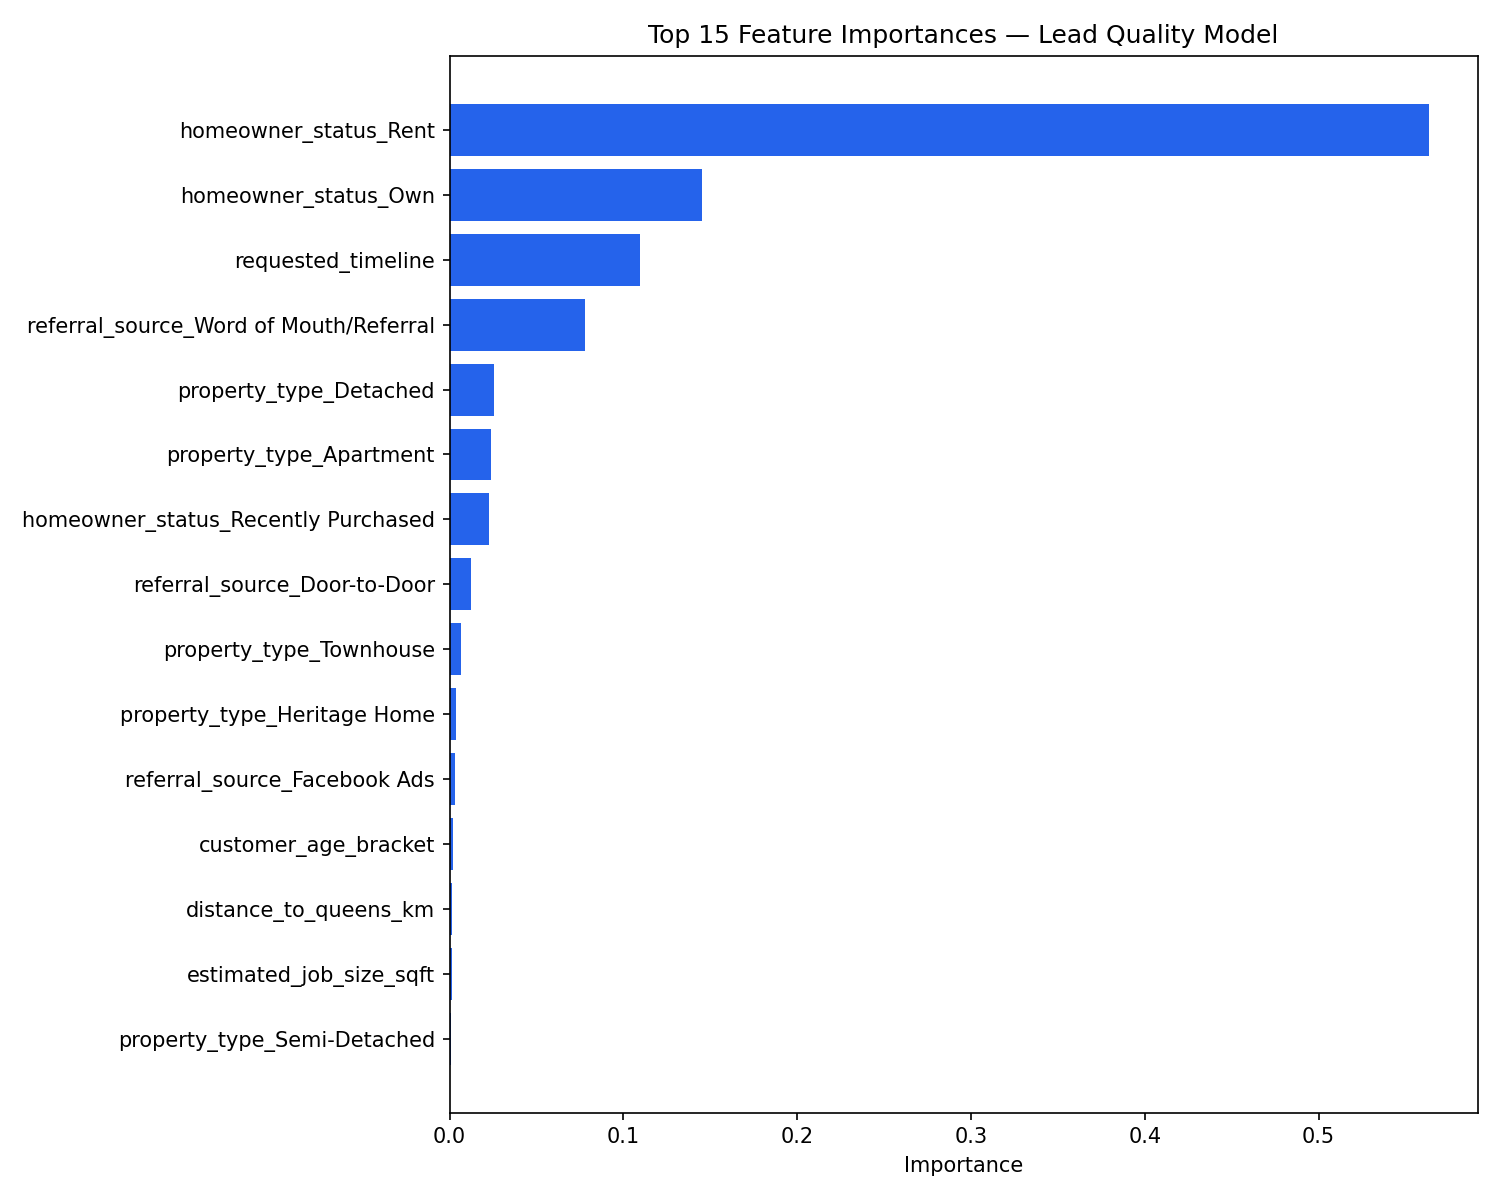

In [6]:
show(
    'eda_feature_importance.png',
    caption=(
        'XGBoost Feature Importance — homeowner_status_Rent = ~0.55 importance (55% of model decision power). '
        'The model independently confirmed what industry research predicted. '
        'Top 4 signals: homeowner status (Rent/Own), timeline urgency, Word of Mouth referral.'
    )
)


### 🎙️ Script (~2:00)

*"The scoring system has two deliberate layers, and understanding why they're separate is the
key to understanding this model.*

*The first layer is pure business logic — no machine learning. It answers one question:
will this person actually hire us? I weighted two factors.*
*Homeowner status: an owner scores 1.0, a renter scores 0.15.*
*Timeline urgency: ASAP scores 1.0, flexible timeline scores 0.20.*
*These weights come from industry conversion benchmarks — ServiceTitan and Velocify both report
urgent-timeline leads convert at 2.3 to 2.5 times the rate of flexible leads. Angi data shows
94% of exterior painting projects are homeowner-initiated. So the weights aren't arbitrary —
they're grounded in published home services data.*

*The second layer is the ML component. I trained an XGBoost model on the 1,250 labeled rows
to predict profit band — Low, Medium, or High — and then used that prediction to score
all 2,500 leads, including the previously unlabeled half.*

*[Feature importance chart] Here's the validation moment.*
*The model was given 8 features and learned which combinations matter most — entirely on its own,
with no guidance from me on what to weight.*
*The result: homeowner status accounts for over 55% of total decision power, with the 'Rent'
flag being the single most important individual feature. Timeline urgency and Word of Mouth
referral follow. The machine independently rediscovered exactly what the research-backed
weights predicted. That's the kind of convergence that makes me confident in the approach.*

*I chose XGBoost specifically because it's the industry standard for tabular datasets at this
scale — it handles missing values natively, trains well on ~1,250 rows, and gives interpretable
feature importances. A neural network would overfit on this data size and add no interpretability.*

*Why multiply and not add: because adding would still give a renter a decent score if they had
a very large job. Multiplying means both conditions must hold simultaneously. A renter
can never rank highly — no matter how large their house. That's correct business behavior."*


---
## SLIDE 4 — The Product

---

**LAYOUT:** 2×2 screenshot grid. Short title + one-line description under each screenshot.

**Slide title:** *"The Tool"*

**Footer quote (subtle, bottom of slide):**
*"Every score comes with a plain-English explanation — no black box."*

---

📸 **[PHOTO: Insert Dashboard screenshot here]**

**Dashboard**
At-a-glance pipeline health: KPI cards, profit band distribution, avg priority score, top 10 leads.

---

📸 **[PHOTO: Insert Lead Table + detail drawer screenshot here]**

**Priority Lead Table**
All 2,500 leads ranked by score. Click any row → plain-English breakdown of the 3 factors
driving its rank (e.g. "Homeowner can authorize work · ASAP timeline · Word-of-mouth referral").

---

📸 **[PHOTO: Insert AI Analyzer result screenshot here]**

**AI Text Analyzer**
Paste any email, voicemail, or chat message. Gemini extracts lead fields automatically.
Priority score in under 5 seconds — zero manual data entry.

---

📸 **[PHOTO: Insert Priority Queue screenshot here]**

**Priority Queue**
The team's daily call list. Add leads from anywhere in the tool.
Track status: To Contact → In Progress → Done.

---

### 🎙️ Script (~2:00)

*"The analysis only creates value if a non-technical sales rep can actually use it.
That shaped every design decision.*

*[Dashboard] The dashboard is the morning view: how many High, Medium, and Low priority leads
are in the pipeline, what the average score looks like, and who the top 10 are.
A manager can assess pipeline health in about 10 seconds.*

*[Lead Table] The leads page shows all 2,500 rows, sorted by priority score.
Each lead has a color-coded badge — green, yellow, or red.
Click any row and a panel slides out showing the three factors driving that score
in plain English: 'Homeowner can authorize the work,' 'ASAP timeline shows commitment,'
'Word-of-mouth referral — trusted source.' The rep always knows why a lead ranks where it does.
There's no black box.*

*[AI Analyzer] This is the intake accelerator. When a rep gets an email or voicemail,
they paste the text in. Google Gemini reads it, extracts the eight lead fields —
property type, homeowner status, timeline, job size, and more — and scores it automatically.
Under 5 seconds, zero manual entry. And it handles informal language:
'bungalow' maps to Detached, 'urgent' maps to ASAP, 'I own the house' maps to homeowner Own.*

*[Queue] The queue is their daily action list. Reps add leads from anywhere in the tool
and work through them in priority order, updating status as they go.
It persists across sessions so no lead falls through the cracks."*


---
## SLIDE 5 — Summary + Next Steps

---

**LAYOUT:** Left = Before/After table. Right = Key Findings (numbered, bold) + Next Steps list.

**Slide title:** *"From Intuition to Data-Driven Prioritization"*

---

#### Before → After

| Before | After |
|---|---|
| Leads called in no particular order | Every lead ranked by expected value |
| Equal time on all inquiries | First call = highest-value opportunity |
| No visibility into pipeline quality | Dashboard: real-time pipeline health |
| Manual data entry from emails/calls | AI-assisted intake in under 5 seconds |
| No explanation for a lead's value | Plain-English scoring factors per lead |
| ~1,250 leads never classified | All 2,500 scored and ranked |

---

#### Key Findings

1. **Homeowner status** is the single most powerful conversion signal — 55% of model decision
   weight, confirmed independently by both industry research and the ML model
2. **Word-of-mouth referrals** produce ~57% High-profit leads vs ~25% for paid channels —
   a direct data input for CREO's marketing budget decisions
3. **1,250 previously unlabeled leads** are now scored and rankable —
   every lead in the database is actionable

---

#### Next Steps

- **Collect real conversion outcomes** → retrain model on actual close data
  (replaces the proxy profit band label with ground truth)
- **A/B test** → measure whether following the priority queue improves CREO's close rate
- **CRM / email integration** → auto-import leads, eliminate manual pasting
- **Mobile view** → field reps can check scores on-site

---

### 🎙️ Script (~1:30)

*"To close — what changed?*

*Before: a flat list. Every lead looks the same.*
*After: every lead has a rank, and that rank is explainable.*

*Three findings I want to leave you with:*

*One — homeowner status is the single most powerful signal.*
*The ML model assigned it 55% of its decision weight without being told to.*
*That validates both the research-backed design and the conversion weight layer.*

*Two — word-of-mouth referrals produce roughly twice the proportion of High-profit leads
compared to paid channels.*
*That's not just a scoring input — it's a direct recommendation for where CREO should
allocate its marketing budget.*

*Three — 1,250 leads that were never classified now have a score.*
*Every lead in the database is actionable from day one.*

*[Pause]*
*The most valuable thing I built here is the infrastructure.*
*Right now, the model trains on a proxy — the manually-labeled profit band.*
*But as CREO's team logs real conversion outcomes — 'we closed this lead, we didn't close
that one' — the model can be retrained on actual data and become significantly more accurate.*
*The pipeline is already built for exactly that.*

*My first recommended next step: start logging outcomes today.*
*Even 100 real conversion records would substantially improve the model's predictions.*

*Thank you."*


---
## Appendix A — Research Sources

*These justify every weighted claim in the scoring model. Have these ready for Q&A.*

| Claim | Source |
|---|---|
| Referral leads convert 3–5× more than cold outreach | Jobber (2023), HubSpot (2023), BrightLocal |
| 94% of exterior painting projects are homeowner-initiated | Angi / HomeAdvisor (2023) |
| New homeowners spend $4k–$9k on improvements year one; painting is the #1 project | NAR (2022), Angi (2022) |
| Urgent-timeline leads convert 2.3–2.5× flexible-timeline leads | ServiceTitan (2023), Velocify |
| 72% of residential painting revenue from detached single-family homes | PDCA, HomeAdvisor |
| Ages 35–64 account for 52% of all home improvement spending | U.S. Census Bureau (2023), Angi (2023), Harvard JCHS |

---

## Appendix B — Likely Q&A Questions

| Question | Answer |
|---|---|
| Why not train on all 2,500 rows? | ~1,250 rows have no label — no target to learn from. Train on the labeled half, predict for the rest. |
| Why multiply, not add? | Adding lets renters score well on job size alone. Multiplying requires both conversion likelihood AND profit potential simultaneously. |
| What if the model is wrong? | It gives probabilities, not hard labels — 60% High confidence scores lower than 90% High. Graceful degradation built in. |
| Why XGBoost over a neural network? | ~1,250 training rows. Neural nets need far more data to avoid overfitting. XGBoost is the industry standard at this scale. |
| Why drop weather / weekday / pets? | No causal mechanism linking them to conversion or job size. Spurious features reduce generalizability. |
| How do you retrain later? | Log conversion outcomes → replace profit_band proxy with real labels → run `python -m ml.model`. Pipeline already built. |
| What does a score of 0.7 mean in dollars? | Currently a relative rank. To convert: multiply by avg job value if converted. Infrastructure ready once CREO has historical close-rate data. |
